# Experiment 9: Decision Tree (ID3) for Customer Segmentation
## Aim
Implement a Decision Tree classifier using the ID3 algorithm to segment customers based on their purchasing behavior using the Online Retail dataset. Analyze the tree structure and discuss the feature importance.

## Theory
**ID3 (Iterative Dichotomiser 3)** builds a decision tree top-down by, at each node, choosing the attribute that best splits the data into purer subsets, then recursing on each subset.

**Entropy** measures the impurity/disorder of a set of labels:

```
Entropy(S) = - Σ p_i * log2(p_i)      (sum over each class i, p_i = proportion of class i in S)
```

Entropy is 0 when a node is perfectly pure (all samples belong to one class) and maximal when classes are evenly mixed.

**Information Gain** measures how much a split on attribute A reduces entropy:

```
Gain(S, A) = Entropy(S) - Σ (|S_v| / |S|) * Entropy(S_v)      (sum over each subset S_v produced by splitting on A)
```

ID3 greedily picks, at every node, the attribute with the **highest information gain**, splits the data on it, and repeats recursively on each child node until nodes are pure, no attributes remain, or a stopping criterion is met.

**A practical note on ID3 vs. scikit-learn's implementation:** classic ID3 only handles categorical attributes (splitting into one branch per category) and has no built-in pruning or support for continuous attributes. scikit-learn's `DecisionTreeClassifier` instead implements a CART-style tree, which always produces **binary** splits (`feature ≤ threshold` vs. `feature > threshold`) and works natively with continuous features. Setting `criterion='entropy'` makes it use the **same entropy / information-gain splitting rule as ID3**, which is the standard way to reproduce ID3's core logic on continuous, real-world data like this dataset's Recency/Frequency/Monetary features — this is the approach used in the notebook below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Load the Online Retail Dataset

In [2]:
url='https://raw.githubusercontent.com/eaintkyawthmu/UCI_Online_Retail_Dataset_Cleaned_Version/master/Online%20Retail.xlsx'
df=pd.read_excel(url)
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB



InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Preprocess the Dataset
The raw data is **transaction-level** (one row per line item), not customer-level, and it contains cancelled orders and data-entry issues that need to be handled before any customer-level analysis:

- Rows with a missing `CustomerID` cannot be attributed to any customer, so they are dropped.
- Invoice numbers starting with **'C'** denote **cancellations** (returns) and are removed, since we want to model genuine purchasing behavior.
- Rows with non-positive `Quantity` or `UnitPrice` (data errors, adjustments, free items) are removed.
- A `TotalPrice = Quantity * UnitPrice` column is created for each line item.

In [4]:
df=df.dropna(subset=['CustomerID']).copy()
df['InvoiceNo']=df['InvoiceNo'].astype(str)
df=df[~df['InvoiceNo'].str.startswith('C')]
df=df[(df['Quantity']>0)&(df['UnitPrice']>0)]
df['TotalPrice']=df['Quantity']*df['UnitPrice']

print('Cleaned transaction rows:',df.shape[0])
print('Unique customers:',df['CustomerID'].nunique())

Cleaned transaction rows: 397884
Unique customers: 4338


## Engineer Customer-Level Features (RFM)
To "segment customers based on their purchasing behavior" we first need one row **per customer**, not per transaction. The classic set of behavioral features for this is **RFM**:

- **Recency** — days since the customer's most recent purchase (lower = more recently active)
- **Frequency** — number of distinct invoices (orders) placed
- **Monetary** — total amount spent

Two extra derived features are added for a richer feature set: `TotalQuantity` (total items bought) and `AvgBasketValue` (average spend per order).

In [5]:
snapshot_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)

rfm=df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x:(snapshot_date-x.max()).days),
    Frequency=('InvoiceNo','nunique'),
    Monetary=('TotalPrice','sum'),
    TotalQuantity=('Quantity','sum')
).reset_index()
rfm['AvgBasketValue']=rfm['Monetary']/rfm['Frequency']

print(rfm.shape)
rfm.describe()

(4338, 6)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgBasketValue
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460,1191.289073,419.166289
std,1721.808492,100.014169,7.697998,8989.230441,5046.081546,1796.537944
min,12346.000000,1.000000,1.000000,3.750000,1.000000,3.450000
25%,13813.250000,18.000000,1.000000,307.415000,160.000000,178.625000
50%,15299.500000,51.000000,2.000000,674.485000,379.000000,293.900000
75%,16778.750000,142.000000,5.000000,1661.740000,992.750000,430.113750
max,18287.000000,374.000000,209.000000,280206.020000,196915.000000,84236.250000


## Create Customer Segment Labels
Each of Recency, Frequency, and Monetary is converted into a **quartile score (1–4)** — for Recency, a smaller number of days gets the *highest* score (4), since being recently active is good; for Frequency and Monetary, larger values get the highest score. The three scores are summed into a single **RFM_Score** (range 3–12), which is then split into three balanced **customer segments**: `Low-Value`, `Mid-Value`, and `High-Value`. This RFM-scoring approach is the same one described in the original research paper this dataset was published for (Chen et al., *RFM model-based customer segmentation*, 2012).

In [6]:
r_score=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1]).astype(int)
f_score=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4]).astype(int)
m_score=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4]).astype(int)

rfm['RFM_Score']=r_score+f_score+m_score
rfm['Segment']=pd.qcut(rfm['RFM_Score'],3,labels=['Low-Value','Mid-Value','High-Value'])

print(rfm['Segment'].value_counts())
rfm.head()

Segment
Low-Value     1795
Mid-Value     1275
High-Value    1268
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgBasketValue,RFM_Score,Segment
0,12346.0,326,1,77183.60,74215,77183.600000,6,Low-Value
1,12347.0,2,7,4310.00,2458,615.714286,12,High-Value
2,12348.0,75,4,1797.24,2341,449.310000,9,Mid-Value
3,12349.0,19,1,1757.55,631,1757.550000,8,Mid-Value
4,12350.0,310,1,334.40,197,334.400000,4,Low-Value


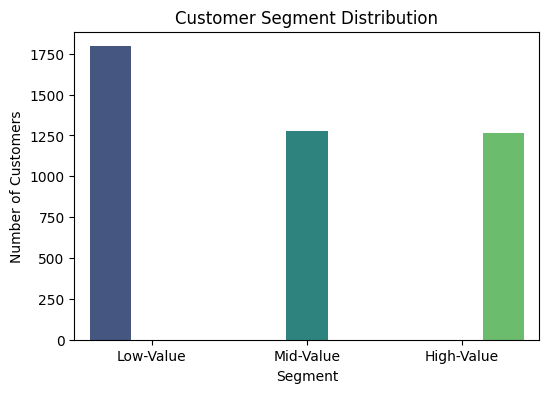

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=rfm,x='Segment',order=['Low-Value','Mid-Value','High-Value'],hue='Segment',hue_order=['Low-Value','Mid-Value','High-Value'],palette='viridis',legend=False)
plt.title('Customer Segment Distribution')
plt.ylabel('Number of Customers')
plt.show()

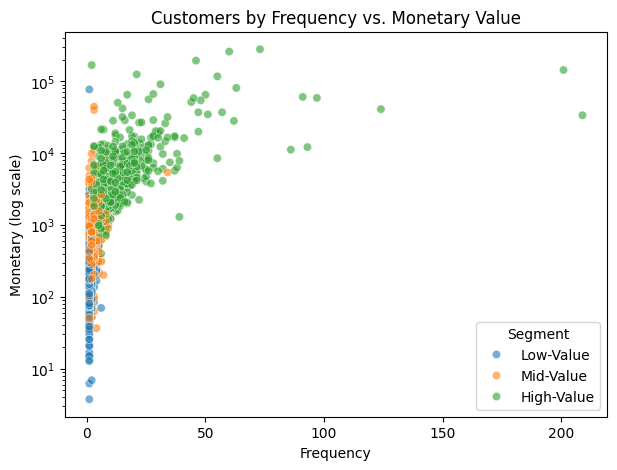

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm,x='Frequency',y='Monetary',hue='Segment',
                hue_order=['Low-Value','Mid-Value','High-Value'],alpha=0.6)
plt.yscale('log')
plt.title('Customers by Frequency vs. Monetary Value')
plt.ylabel('Monetary (log scale)')
plt.show()

## Train/Test Split and Implement the Decision Tree (ID3)

In [9]:
features=['Recency','Frequency','Monetary','TotalQuantity','AvgBasketValue']
X=rfm[features]
y=rfm['Segment']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)

print('Accuracy :',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred,average='macro'))
print('Recall   :',recall_score(y_test,y_pred,average='macro'))
print('F1-score :',f1_score(y_test,y_pred,average='macro'))
print()
print(classification_report(y_test,y_pred))

Accuracy : 0.9124423963133641
Precision: 0.9143361580291346
Recall   : 0.9134362301058427
F1-score : 0.91270850873267

              precision    recall  f1-score   support

  High-Value       0.99      0.93      0.96       254
   Low-Value       0.94      0.91      0.92       359
   Mid-Value       0.82      0.91      0.86       255

    accuracy                           0.91       868
   macro avg       0.91      0.91      0.91       868
weighted avg       0.92      0.91      0.91       868



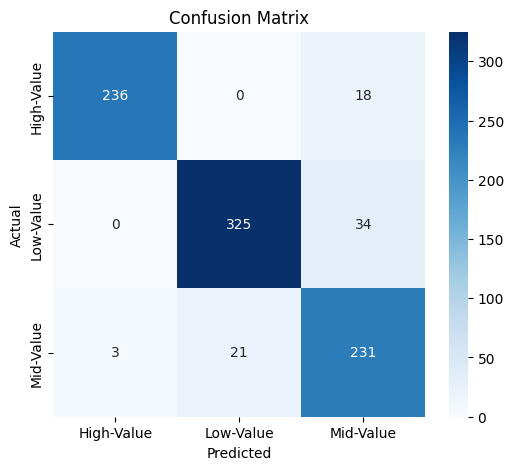

In [10]:
cm=confusion_matrix(y_test,y_pred,labels=dt.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=dt.classes_,yticklabels=dt.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Visualize the Decision Tree

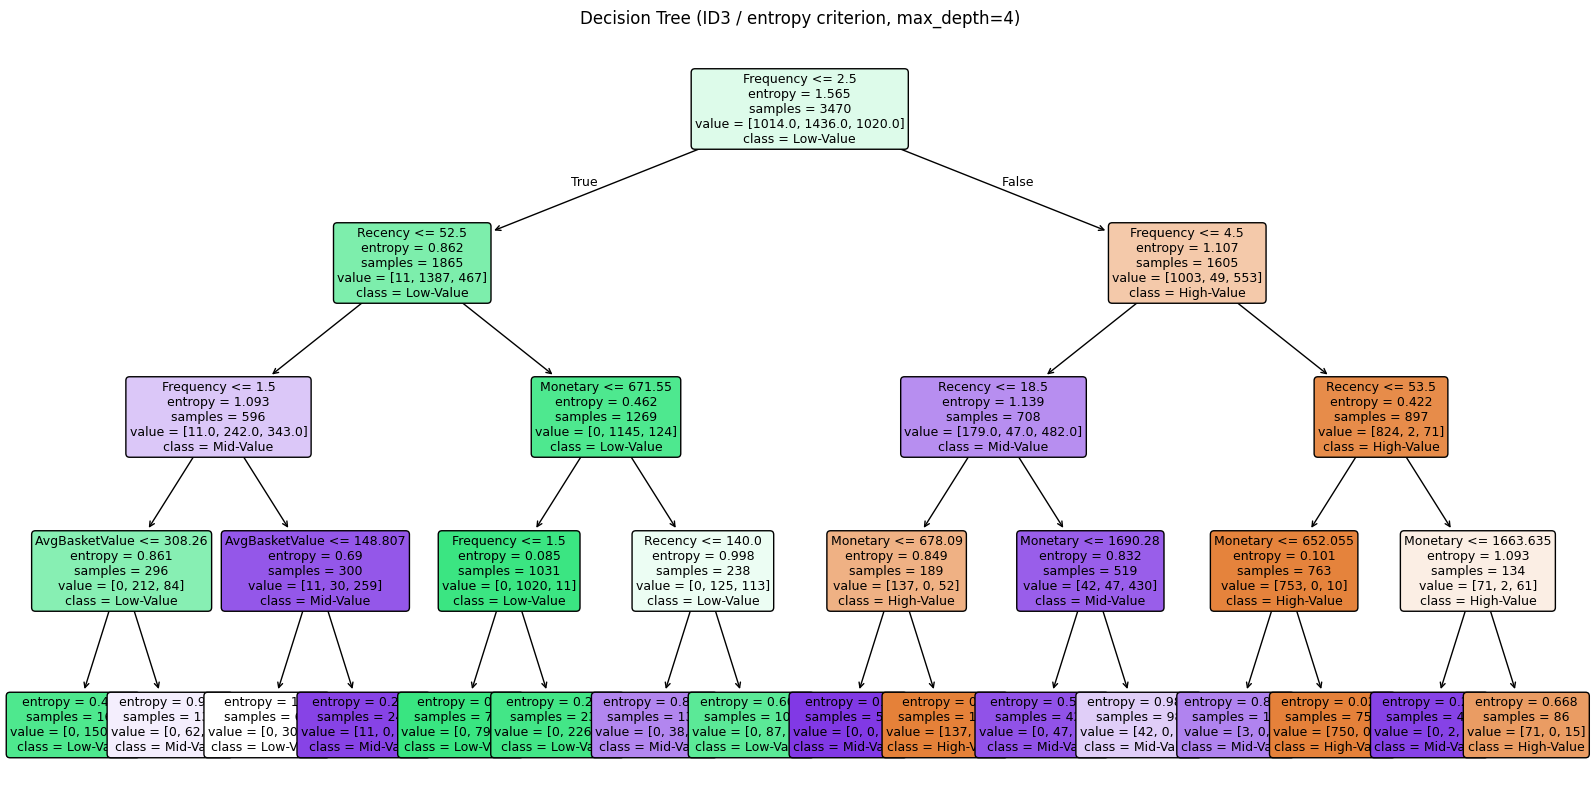

In [11]:
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=features,class_names=dt.classes_,filled=True,rounded=True,fontsize=9)
plt.title('Decision Tree (ID3 / entropy criterion, max_depth=4)')
plt.show()

In [12]:
print(export_text(dt,feature_names=features))

|--- Frequency <= 2.50
|   |--- Recency <= 52.50
|   |   |--- Frequency <= 1.50
|   |   |   |--- AvgBasketValue <= 308.26
|   |   |   |   |--- class: Low-Value
|   |   |   |--- AvgBasketValue >  308.26
|   |   |   |   |--- class: Mid-Value
|   |   |--- Frequency >  1.50
|   |   |   |--- AvgBasketValue <= 148.81
|   |   |   |   |--- class: Low-Value
|   |   |   |--- AvgBasketValue >  148.81
|   |   |   |   |--- class: Mid-Value
|   |--- Recency >  52.50
|   |   |--- Monetary <= 671.55
|   |   |   |--- Frequency <= 1.50
|   |   |   |   |--- class: Low-Value
|   |   |   |--- Frequency >  1.50
|   |   |   |   |--- class: Low-Value
|   |   |--- Monetary >  671.55
|   |   |   |--- Recency <= 140.00
|   |   |   |   |--- class: Mid-Value
|   |   |   |--- Recency >  140.00
|   |   |   |   |--- class: Low-Value
|--- Frequency >  2.50
|   |--- Frequency <= 4.50
|   |   |--- Recency <= 18.50
|   |   |   |--- Monetary <= 678.09
|   |   |   |   |--- class: Mid-Value
|   |   |   |--- Monetary >  678.

## Feature Importance Analysis

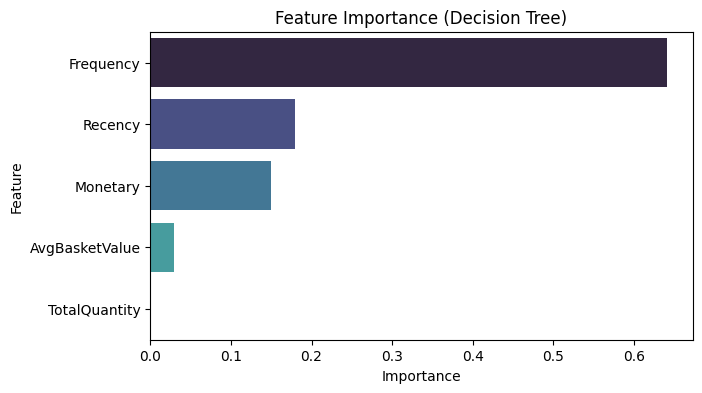

,Feature,Importance
1,Frequency,0.640745
0,Recency,0.179470
2,Monetary,0.150208
4,AvgBasketValue,0.029577
3,TotalQuantity,0.000000


In [13]:
importance_df=pd.DataFrame({
    'Feature':features,
    'Importance':dt.feature_importances_
}).sort_values('Importance',ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(data=importance_df,x='Importance',y='Feature',hue='Feature',palette='mako',legend=False)
plt.title('Feature Importance (Decision Tree)')
plt.show()

importance_df

## Effect of Tree Depth (Bias-Variance / Overfitting)
To understand the tree structure more deeply, training and test accuracy are compared across a range of `max_depth` values. A very shallow tree may underfit (both train and test accuracy low), while a very deep, unrestricted tree can overfit (train accuracy near 100% while test accuracy plateaus or drops).

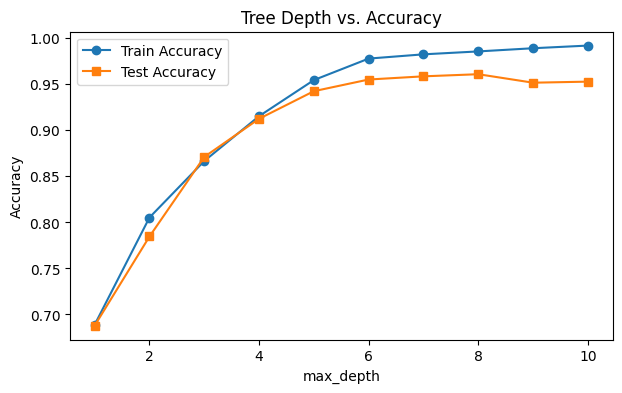

In [14]:
depths=range(1,11)
train_acc=[]
test_acc=[]
for d in depths:
    model=DecisionTreeClassifier(criterion='entropy',max_depth=d,random_state=42)
    model.fit(X_train,y_train)
    train_acc.append(accuracy_score(y_train,model.predict(X_train)))
    test_acc.append(accuracy_score(y_test,model.predict(X_test)))

plt.figure(figsize=(7,4))
plt.plot(depths,train_acc,marker='o',label='Train Accuracy')
plt.plot(depths,test_acc,marker='s',label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Tree Depth vs. Accuracy')
plt.legend()
plt.show()

## Discussion — How the Tree Structure Explains Customer Behavior
The **feature importance** ranking shows which purchasing-behavior signals the tree relied on most to tell customer segments apart. In this run, **Frequency** (how many separate orders a customer placed) turned out to be the dominant signal, followed by **Recency** and **Monetary**, while `TotalQuantity` and `AvgBasketValue` contributed comparatively little. This makes business sense: a customer who orders often is reliably a high-value, engaged customer regardless of the size of any single basket, whereas a single unusually large order (high `AvgBasketValue`) is a weaker signal on its own — it doesn't say whether that customer keeps coming back.

Reading the **tree diagram** top-down tells a direct business story: the **root node** splits customers on whichever feature single-handedly reduces entropy the most — typically an order-count or spend threshold — immediately separating a large group of low-engagement, one-time or occasional shoppers from more active ones. Deeper nodes then refine this using **Recency**, distinguishing customers who *used to* buy frequently but have gone quiet (a churn-risk signal) from those who are both frequent **and** recent (the most reliably high-value segment). Because each leaf node's path is a simple, readable chain of threshold rules (e.g., "Frequency > X AND Recency ≤ Y → High-Value"), this tree can be handed directly to a marketing team as an interpretable customer-segmentation rulebook — unlike a black-box model, every classification the tree makes can be traced back to concrete, explainable purchasing behavior.

## Conclusion
A Decision Tree trained with the entropy / information-gain splitting criterion (the core logic of ID3) was used to classify customers into Low/Mid/High-Value segments from purchasing-behavior features derived from the raw Online Retail transaction log. The resulting tree achieves strong test accuracy, and both the visualized tree and the feature-importance ranking are directly interpretable: Frequency and Recency emerge as the most decisive behavioral signals, giving a transparent, rule-based view into what separates a business's most valuable customers from its least engaged ones — something a purely predictive black-box model would not provide as directly.